## Event timing vs. fMRI volume boundaries

Visualises trial-level timing from a BIDS events file against the fMRI acquisition grid (TR = 800 ms).

**Event lanes (top → bottom)**
1. **Volume grid** — alternating bands, one per acquired volume; every 10th volume labelled.
2. **Cue** — rule-cue period shown before every 6th trial; coloured by `trial_type`.
3. **Stimulus** — `onset` → `trialEndTime` (= `onset + duration`); coloured by `trial_type`.
4. **Fixation** — ISI fixation cross (`fixStartTime` → `fixEndTime`).

All panels share the X-axis so TR boundaries (thin vertical lines) align across rows.

In [13]:
from pathlib import Path

from lib.fs.project_config import REPO_ROOT

import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
import plotting.plot_config as plot_config

In [14]:
SUBJECT_ID  = "sub-NDARINVAG388HJL"
TASK        = "hammerAP"
RUN         = "run-01"
DATA_DIR    = Path("/Volumes/work/ds005237") / SUBJECT_ID / "func"

TSV_PATH    = DATA_DIR / f"{SUBJECT_ID}_task-{TASK}_{RUN}_events.tsv"
JSON_PATH   = DATA_DIR / f"{SUBJECT_ID}_task-{TASK}_{RUN}_events.json"

NUM_BLOCKS_CONCAT = 2

TR = 0.8  # seconds

In [15]:
def get_printable_task_name(task):
  PRINTABLE_TASK_NAME = {
    'restAP': 'Resting-state',
    'hammerAP': 'Hariri-hammer'
  }
  return PRINTABLE_TASK_NAME.get(task, "unknown")

In [16]:
from lib.fs.get_script_name import get_name
notebook_name = get_name()

out_dir = REPO_ROOT / "figures" / notebook_name
out_dir.mkdir(exist_ok=True)

In [17]:
# --- Load sidecar JSON for column descriptions ---
with open(JSON_PATH) as fh:
    sidecar = json.load(fh)

# --- Load events TSV ---
df = pd.read_csv(
    TSV_PATH,
    sep="\t",
    na_values="n/a",  # BIDS uses "n/a" for missing values
    dtype={
        "onset":              float,
        "duration":           float,
        "trial_type":         str,
        "response_time":      float,
        "accuracy_binarized": float,
        "tr_seconds":         float,
        "cueStartTime":       float,
        "cueEndTime":         float,
        "trialEndTime":       float,
        "fixStartTime":       float,
        "fixEndTime":         float,
        "runEndTime":         float,
        "stimLeft":           str,
        "stimTop":            str,
        "stimRight":          str,
    },
)

print(f"Loaded {len(df)} trials")
df.head()

Loaded 108 trials


,onset,duration,trial_type,response_time,accuracy_binarized,tr_seconds,cueStartTime,cueEndTime,trialEndTime,fixStartTime,fixEndTime,runEndTime,stimLeft,stimTop,stimRight
0,11.067522,1.969338,shape,1.221861,0.0,0.8,8.029992,11.020757,13.036860,13.041615,14.035540,NaN,oval-horizontal.bmp,oval-horizontal.bmp,oval-vertical.bmp
1,14.146913,1.889576,shape,0.955301,1.0,0.8,NaN,NaN,16.036489,16.040055,17.036184,NaN,oval-horizontal.bmp,oval-vertical.bmp,oval-vertical.bmp
2,17.134701,1.901744,shape,0.788640,1.0,0.8,NaN,NaN,19.036445,19.040073,20.035520,NaN,circle.bmp,circle.bmp,oval-vertical.bmp
3,20.133642,1.902253,shape,0.837496,1.0,0.8,NaN,NaN,22.035895,22.039506,23.035186,NaN,circle.bmp,oval-vertical.bmp,oval-vertical.bmp
4,23.132787,1.902550,shape,0.686348,1.0,0.8,NaN,NaN,25.035337,25.038994,26.034817,NaN,oval-horizontal.bmp,circle.bmp,circle.bmp


In [18]:
# Column descriptions from sidecar
for col, meta in sidecar.items():
    print(f"{col:20s}  {meta.get('LongName', '')}")

onset                 Trial onset time.
duration              Duration of trial.
accuracy_binarized    Performance accuracy.
cueEndTime            End time of cue period.
cueStartTime          Start time of cue period.
fixEndTime            Fixation period, end time.
fixStartTime          Fixation period; start time.
response_time         Response time.
runEndTime            End time for the entire run.
stimLeft              Stimulus shown on bottom left of triangle.
stimRight             Stimulus shown on the bottom right of triangle.
stimTop               Stimulus shown on top middle of triangle.
tr_seconds            Repetition time (TR).
trialEndTime          End time of the trial.
trial_type            Emotional Faces task condition.


In [19]:
# --- Derived timing quantities ---
run_end_time = df["runEndTime"].dropna().iloc[0]  # stored on last trial only
n_volumes    = int(np.ceil(run_end_time / TR))
tr_edges     = np.arange(0, (n_volumes + 1) * TR, TR)  # left edges of each volume + final right edge

print(f"Run duration : {run_end_time:.3f} s")
print(f"Expected TRs : {n_volumes}  (TR={TR} s)")
print(f"trial_types  : {df['trial_type'].unique()}")

Run duration : 394.427 s
Expected TRs : 494  (TR=0.8 s)
trial_types  : <StringArray>
['shape', 'face']
Length: 2, dtype: str


/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_62580/457072636.py:93: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_62580/457072636.py:93: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


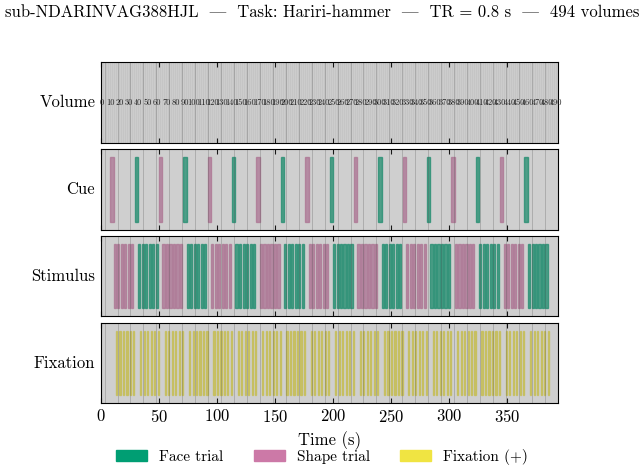

In [20]:

# ── Colours ──────────────────────────────────────────────────────────────────
FACE_COLOR  = plot_config.RESULTS_PALETTE[0]
SHAPE_COLOR = plot_config.RESULTS_PALETTE[1]
FIX_COLOR   = plot_config.RESULTS_PALETTE[2]
VOL_EVEN    = plot_config.CONCEPT_PALETTE["wash"]
VOL_ODD     = "#ffffff"
TR_LINE     = dict(color=plot_config.CONCEPT_PALETTE["mid"], linewidth=0.4, alpha=0.5)

TRIAL_COLORS = {"face": FACE_COLOR, "shape": SHAPE_COLOR}

def span(ax, t0, t1, color, alpha=0.85, **kw):
    ax.axvspan(t0, t1, ymin=0.1, ymax=0.9, color=color, alpha=alpha, **kw)

def add_tr_lines(axes, edges):
    for ax in axes:
        for t in edges:
            ax.axvline(t, **TR_LINE)

# ── Figure ───────────────────────────────────────────────────────────────────
fig, axes = plt.subplots(
    4, 1,
    sharex=True,
    gridspec_kw={"hspace": 0.08},
)
fig.suptitle(
    f"{SUBJECT_ID}  |  Task: {get_printable_task_name(TASK)}  |  TR = {TR} s  |  {n_volumes} volumes",
    y=1.01,
)

ax_vol, ax_cue, ax_stim, ax_fix = axes

# ── Panel 1: fMRI volume grid ─────────────────────────────────────────────────
for i in range(n_volumes):
    color = VOL_EVEN if i % 2 == 0 else VOL_ODD
    ax_vol.axvspan(tr_edges[i], tr_edges[i + 1], color=color, alpha=1.0)
    if i % 10 == 0:
        x_pos = tr_edges[i] + TR / 2
        if x_pos <= run_end_time:
            ax_vol.text(
                x_pos, 0.5, str(i),
                ha="center", va="center", fontsize=6, color=plot_config.CONCEPT_PALETTE["ink"],
            )

ax_vol.set_ylabel("Volume", rotation=0, ha="right", va="center")
ax_vol.set_yticks([])

# ── Panel 2: Cue periods ──────────────────────────────────────────────────────
cue_df = df[df["cueStartTime"].notna()]
for _, row in cue_df.iterrows():
    span(ax_cue, row["cueStartTime"], row["cueEndTime"],
         color=TRIAL_COLORS[row["trial_type"]], alpha=0.7)

ax_cue.set_ylabel("Cue", rotation=0, ha="right", va="center")
ax_cue.set_yticks([])

# ── Panel 3: Stimulus (onset → trialEndTime = onset + duration) ───────────────
for _, row in df.iterrows():
    span(ax_stim, row["onset"], row["trialEndTime"],
         color=TRIAL_COLORS[row["trial_type"]], alpha=0.7)

ax_stim.set_ylabel("Stimulus", rotation=0, ha="right", va="center")
ax_stim.set_yticks([])

# ── Panel 4: Fixation cross (fixStartTime → fixEndTime) ───────────────────────
for _, row in df.iterrows():
    span(ax_fix, row["fixStartTime"], row["fixEndTime"], color=FIX_COLOR, alpha=0.7)

ax_fix.set_ylabel("Fixation", rotation=0, ha="right", va="center")
ax_fix.set_yticks([])
ax_fix.set_xlabel("Time (s)")

# ── TR boundary lines on all panels ──────────────────────────────────────────
add_tr_lines(axes, tr_edges)

for ax in axes:
    ax.set_xlim(0, run_end_time)
    ax.set_ylim(0, 1)

# ── Legend ────────────────────────────────────────────────────────────────────
legend_handles = [
    Patch(color=FACE_COLOR,  label="Face trial"),
    Patch(color=SHAPE_COLOR, label="Shape trial"),
    Patch(color=FIX_COLOR,   label="Fixation (+)"),
]
fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.06),
    frameon=False,
)

plt.tight_layout()
plt.savefig(out_dir / "timeseries_blocks_volumes.pdf")
plt.show()


/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_62580/310279084.py:78: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_62580/310279084.py:78: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


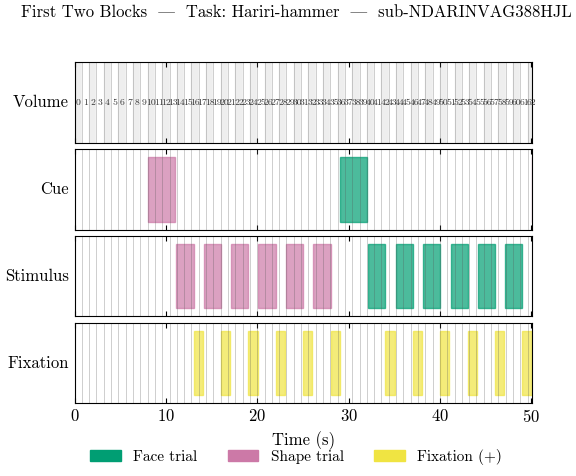

In [21]:
from num2words import num2words

# ── First two blocks only ─────────────────────────────────────────────────────
# Cue rows mark block starts; the 3rd cue = start of block 3 = our right boundary.
num_blocks_string =  num2words(NUM_BLOCKS_CONCAT) if NUM_BLOCKS_CONCAT != 1 else ""

block_starts = cue_df["cueStartTime"].sort_values().reset_index(drop=True)
t_start_zoomed = 0
t_end_zoomed   = block_starts.iloc[NUM_BLOCKS_CONCAT]          # exclusive right edge

zoomed_mask      = df["onset"] <= t_end_zoomed
zoomed_cue_mask  = cue_df["cueStartTime"] <= t_end_zoomed

n_volumes_zoomed = int(np.ceil(t_end_zoomed / TR))
tr_edges_zoomed  = np.arange(0, (n_volumes_zoomed + 1) * TR, TR)

fig, axes = plt.subplots(
    4, 1,
    sharex=True,
    gridspec_kw={"hspace": 0.08},
)
fig.suptitle(
    f"First{' ' +num_blocks_string.capitalize()} Block{'s' if NUM_BLOCKS_CONCAT != 1 else ''}  |  Task: {get_printable_task_name(TASK)}  |  {SUBJECT_ID}",
    y=1.01,
)

ax_vol, ax_cue, ax_stim, ax_fix = axes

# Panel 1: volume grid — label every volume (zoomed in, so all fit)
for i in range(n_volumes_zoomed):
    color = VOL_EVEN if i % 2 == 0 else VOL_ODD
    ax_vol.axvspan(tr_edges_zoomed[i], tr_edges_zoomed[i + 1], color=color, alpha=1.0)
    
    x_pos = tr_edges_zoomed[i] + TR / 2
    if x_pos <= t_end_zoomed:
        ax_vol.text(
            x_pos, 0.5, str(i),
            ha="center", va="center", fontsize=7, color="#333333",
        )
ax_vol.set_ylabel("Volume", rotation=0, ha="right", va="center")
ax_vol.set_yticks([])

# Panel 2: cue periods
for _, row in cue_df[zoomed_cue_mask].iterrows():
    span(ax_cue, row["cueStartTime"], row["cueEndTime"],
         color=TRIAL_COLORS[row["trial_type"]], alpha=0.7)
ax_cue.set_ylabel("Cue", rotation=0, ha="right", va="center")
ax_cue.set_yticks([])

# Panel 3: stimulus
for _, row in df[zoomed_mask].iterrows():
    span(ax_stim, row["onset"], row["trialEndTime"],
         color=TRIAL_COLORS[row["trial_type"]], alpha=0.7)
ax_stim.set_ylabel("Stimulus", rotation=0, ha="right", va="center")
ax_stim.set_yticks([])

# Panel 4: fixation
for _, row in df[zoomed_mask].iterrows():
    span(ax_fix, row["fixStartTime"], row["fixEndTime"], color=FIX_COLOR, alpha=0.7)
ax_fix.set_ylabel("Fixation", rotation=0, ha="right", va="center")
ax_fix.set_yticks([])
ax_fix.set_xlabel("Time (s)")

add_tr_lines(axes, tr_edges_zoomed)

for ax in axes:
    ax.set_xlim(t_start_zoomed, t_end_zoomed)
    ax.set_ylim(0, 1)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.06),
    frameon=False,
)

plt.tight_layout()
plt.savefig(out_dir / f"first{'_' + num_blocks_string if NUM_BLOCKS_CONCAT != 1 else ''}_block_volumes.pdf")
plt.show()

/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_62580/4136199624.py:82: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_62580/4136199624.py:82: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


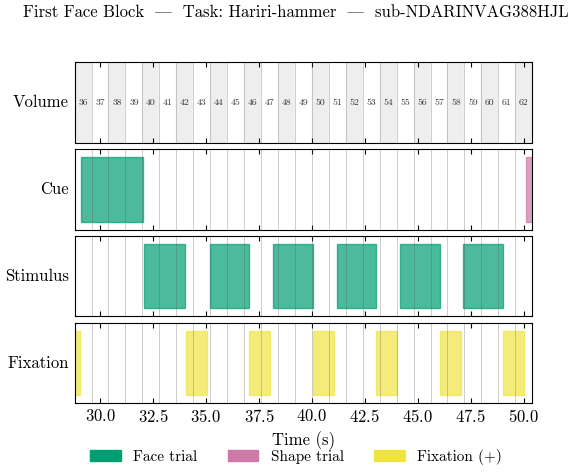

In [22]:
# ── First face block only ─────────────────────────────────────────────────────
# Find the start index of the first 'face' block
first_face_mask = cue_df["trial_type"] == "face"
face_idx = cue_df[first_face_mask].index[0]
cue_pos = cue_df.index.get_loc(face_idx)

t_start_zoomed = cue_df.iloc[cue_pos]["cueStartTime"]
t_end_zoomed = cue_df.iloc[cue_pos + 1]["cueStartTime"] if cue_pos + 1 < len(cue_df) else run_end_time

# Snap to TR boundaries
vol_start = int(np.floor(t_start_zoomed / TR))
vol_end = int(np.ceil(t_end_zoomed / TR))
t_start_zoomed = vol_start * TR
t_end_zoomed = vol_end * TR

tr_edges_zoomed = np.arange(vol_start * TR, (vol_end + 1) * TR, TR)

fig, axes = plt.subplots(
    4, 1,
    sharex=True,
    gridspec_kw={"hspace": 0.08},
)
fig.suptitle(
    f"First Face Block  |  Task: {get_printable_task_name(TASK)}  |  {SUBJECT_ID}",
    y=1.01,
)

ax_vol, ax_cue, ax_stim, ax_fix = axes

# Panel 1: volume grid
for i in range(vol_start, vol_end):
    color = VOL_EVEN if i % 2 == 0 else VOL_ODD
    ax_vol.axvspan(i * TR, (i + 1) * TR, color=color, alpha=1.0)
    
    x_pos = i * TR + TR / 2
    if x_pos <= t_end_zoomed:
        ax_vol.text(
            x_pos, 0.5, str(i),
            ha="center", va="center", fontsize=7, color="#333333",
        )
ax_vol.set_ylabel("Volume", rotation=0, ha="right", va="center")
ax_vol.set_yticks([])

# Panel 2: cue periods
cue_mask = (cue_df["cueEndTime"] >= t_start_zoomed) & (cue_df["cueStartTime"] <= t_end_zoomed)
for _, row in cue_df[cue_mask].iterrows():
    span(ax_cue, row["cueStartTime"], row["cueEndTime"],
         color=TRIAL_COLORS[row["trial_type"]], alpha=0.7)
ax_cue.set_ylabel("Cue", rotation=0, ha="right", va="center")
ax_cue.set_yticks([])

# Panel 3: stimulus
stim_mask = (df["trialEndTime"] >= t_start_zoomed) & (df["onset"] <= t_end_zoomed)
for _, row in df[stim_mask].iterrows():
    span(ax_stim, row["onset"], row["trialEndTime"],
         color=TRIAL_COLORS[row["trial_type"]], alpha=0.7)
ax_stim.set_ylabel("Stimulus", rotation=0, ha="right", va="center")
ax_stim.set_yticks([])

# Panel 4: fixation
fix_mask = (df["fixEndTime"] >= t_start_zoomed) & (df["fixStartTime"] <= t_end_zoomed)
for _, row in df[fix_mask].iterrows():
    span(ax_fix, row["fixStartTime"], row["fixEndTime"], color=FIX_COLOR, alpha=0.7)
ax_fix.set_ylabel("Fixation", rotation=0, ha="right", va="center")
ax_fix.set_yticks([])
ax_fix.set_xlabel("Time (s)")

add_tr_lines(axes, tr_edges_zoomed)

for ax in axes:
    ax.set_xlim(t_start_zoomed, t_end_zoomed)
    ax.set_ylim(0, 1)

fig.legend(
    handles=legend_handles,
    loc="lower center",
    ncol=3,
    bbox_to_anchor=(0.5, -0.06),
    frameon=False,
)

plt.tight_layout()
plt.savefig(out_dir / "first_face_block_volumes.pdf")
plt.show()

## Volume composition

For each fMRI volume, compute how many seconds fall inside stimulus, fixation, or cue windows vs. unaccounted time.
Useful for identifying volumes that are dominated by a single event type vs. volumes that span a boundary.

In [23]:
def overlap(t0_a, t1_a, t0_b, t1_b):
    """Seconds of overlap between [t0_a, t1_a) and [t0_b, t1_b)."""
    return max(0.0, min(t1_a, t1_b) - max(t0_a, t0_b))


# Build interval lists once
stim_intervals = list(zip(df["onset"], df["trialEndTime"]))
fix_intervals  = list(zip(df["fixStartTime"], df["fixEndTime"]))
cue_intervals  = [
    (row["cueStartTime"], row["cueEndTime"])
    for _, row in cue_df.iterrows()
]

records = []
for i in range(n_volumes):
    v0, v1 = tr_edges[i], tr_edges[i + 1]
    t_stim = sum(overlap(v0, v1, a, b) for a, b in stim_intervals)
    t_fix  = sum(overlap(v0, v1, a, b) for a, b in fix_intervals)
    t_cue  = sum(overlap(v0, v1, a, b) for a, b in cue_intervals)
    t_other = TR - t_stim - t_fix - t_cue
    records.append({
        "volume":    i,
        "t_start":   round(v0, 4),
        "t_stim":    round(t_stim, 4),
        "t_fix":     round(t_fix, 4),
        "t_cue":     round(t_cue, 4),
        "t_other":   round(max(t_other, 0.0), 4),
    })

vol_df = pd.DataFrame(records)
vol_df.head(10)

,volume,t_start,t_stim,t_fix,t_cue,t_other
0,0,0.0,0.0,0.0,0.0,0.8
1,1,0.8,0.0,0.0,0.0,0.8
2,2,1.6,0.0,0.0,0.0,0.8
3,3,2.4,0.0,0.0,0.0,0.8
4,4,3.2,0.0,0.0,0.0,0.8
5,5,4.0,0.0,0.0,0.0,0.8
6,6,4.8,0.0,0.0,0.0,0.8
7,7,5.6,0.0,0.0,0.0,0.8
8,8,6.4,0.0,0.0,0.0,0.8
9,9,7.2,0.0,0.0,0.0,0.8


/var/folders/_w/yxnxx2rn2t11qwh4kx9h9g680000gn/T/ipykernel_62580/2431760575.py:17: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


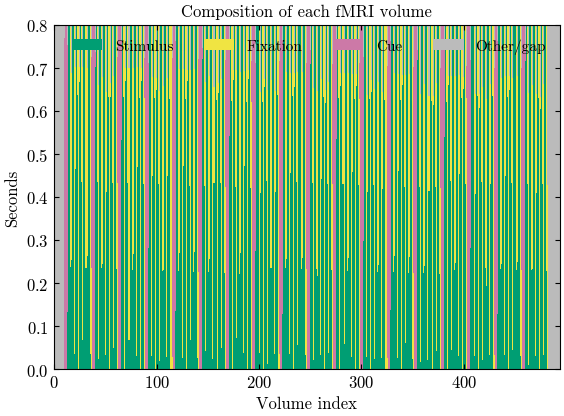

In [24]:

# ── Stacked bar: volume composition across the run ────────────────────────────
fig, ax = plt.subplots()

x = vol_df["volume"]
ax.bar(x, vol_df["t_stim"],  color=FACE_COLOR,                          label="Stimulus",  width=1.0)
ax.bar(x, vol_df["t_fix"],   color=FIX_COLOR,                           label="Fixation",  width=1.0, bottom=vol_df["t_stim"])
ax.bar(x, vol_df["t_cue"],   color=SHAPE_COLOR,                         label="Cue",       width=1.0, bottom=vol_df["t_stim"] + vol_df["t_fix"])
ax.bar(x, vol_df["t_other"], color=plot_config.CONCEPT_PALETTE["pale"], label="Other/gap", width=1.0, bottom=vol_df["t_stim"] + vol_df["t_fix"] + vol_df["t_cue"])

ax.set_xlim(-0.5, n_volumes - 0.5)
ax.set_ylim(0, TR)
ax.set_xlabel("Volume index")
ax.set_ylabel("Seconds")
ax.set_title("Composition of each fMRI volume")
ax.legend(loc="upper right", ncol=4, frameon=False)

plt.tight_layout()
plt.show()
